<a href="https://colab.research.google.com/github/gauravpatra03-sketch/Deep-Learning/blob/main/GenAI_Week3_Ex3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [1]:
import tensorflow as tf
from keras import layers, Model
import matplotlib.pyplot as plt

Load Dataset

In [3]:
(x_train, _), (x_test, _)=tf.keras.datasets.mnist.load_data()

x_train=x_train.astype("float32")/255.0
x_test=x_test.astype("float32")/255.0

x_train=x_train.reshape(-1,784)
x_test=x_test.reshape(-1,784)

print(x_train.shape)
print(x_test.shape)

(60000, 784)
(10000, 784)


Sampling Layer

In [4]:
latent_dim=16

class Sampling(layers.Layer):
  def call(self,inputs):
    z_mean, z_log_var=inputs

    epsilon=tf.random.normal(
        shape=tf.shape(z_mean)
    )

    return z_mean+tf.exp(0.5*z_log_var)*epsilon

Encoder

In [5]:
encoder_inputs=layers.Input(shape=(784,))

x=layers.Dense(256,activation="relu")(encoder_inputs)

z_mean=layers.Dense(latent_dim,name="z_mean")(x)
z_log_var=layers.Dense(latent_dim,name="z_log_var")(x)

z=Sampling()([z_mean,z_log_var])

encoder=Model(
    encoder_inputs,
    [z_mean, z_log_var,z],
    name="Encoder"
)

Decoder

In [11]:
latent_inputs=layers.Input(shape=(latent_dim,))

x=layers.Dense(256, activation="relu")(latent_inputs)

decoder_outputs=layers.Dense(
    784,
    activation="sigmoid"
)(x)

decoder=Model(
    latent_inputs,
    decoder_outputs,
    name="Decoder"
)

VAE Model

In [17]:
class VAE(Model):

  def __init__(self,encoder,decoder):
    super().__init__()

    self.encoder=encoder
    self.decoder=decoder

  def call(self, inputs):
    z_mean,z_log_var,z=self.encoder(inputs)
    reconstruction=self.decoder(z)
    return reconstruction

  def train_step(self,data):

    if isinstance(data,tuple):
      data=data[0]

    with tf.GradientTape() as tape:
      z_mean,z_log_var,z=self.encoder(data)

      reconstruction=self.decoder(z)

      #Reconstruction Loss
      reconstruction_loss=tf.reduce_mean(
          tf.keras.losses.binary_crossentropy(
              data,
              reconstruction
          )
      )

      #KL Divergence Loss
      kl_loss=-0.5*tf.reduce_mean(
          1+z_log_var
          -tf.square(z_mean)
          -tf.exp(z_log_var)
      )

      #Total Loss
      total_loss=reconstruction_loss+kl_loss

    grads=tape.gradient(
        total_loss,
        self.trainable_weights
    )

    self.optimizer.apply_gradients(
        zip(grads, self.trainable_weights)
    )

    return {
        "loss": total_loss,
        "reconstruction_loss": reconstruction_loss,
        "kl_loss":kl_loss
    }

Create VAE

In [18]:
vae= VAE(
    encoder,
    decoder
)

vae.compile(
    optimizer="adam"
)

Train VAE

In [19]:
history=vae.fit(
    x_train,
    epochs=10,
    batch_size=128
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - kl_loss: 2.4955e-04 - loss: 0.2702 - reconstruction_loss: 0.2699
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - kl_loss: 3.2053e-04 - loss: 0.2656 - reconstruction_loss: 0.2653
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - kl_loss: 3.5731e-04 - loss: 0.2665 - reconstruction_loss: 0.2661
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - kl_loss: 2.3641e-04 - loss: 0.2653 - reconstruction_loss: 0.2650
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - kl_loss: 2.0106e-04 - loss: 0.2717 - reconstruction_loss: 0.2715
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - kl_loss: 1.3142e-04 - loss: 0.2682 - reconstruction_loss: 0.2680
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - kl_loss: 5.8338e-05 - loss: 0.2642 - reconstruction_loss: 0.2641
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - kl_loss: 3.0322e-05 - loss: 0.2692 - reconstruction_loss: 0.2691
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━

Reconstruct Test Images

In [20]:
z_mean, z_log_var, z=encoder.predict(
    x_test[:10]
)
reconstructed=decoder.predict(z)
reconstructed.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


(10, 784)

Plot Original vs Reconstruction

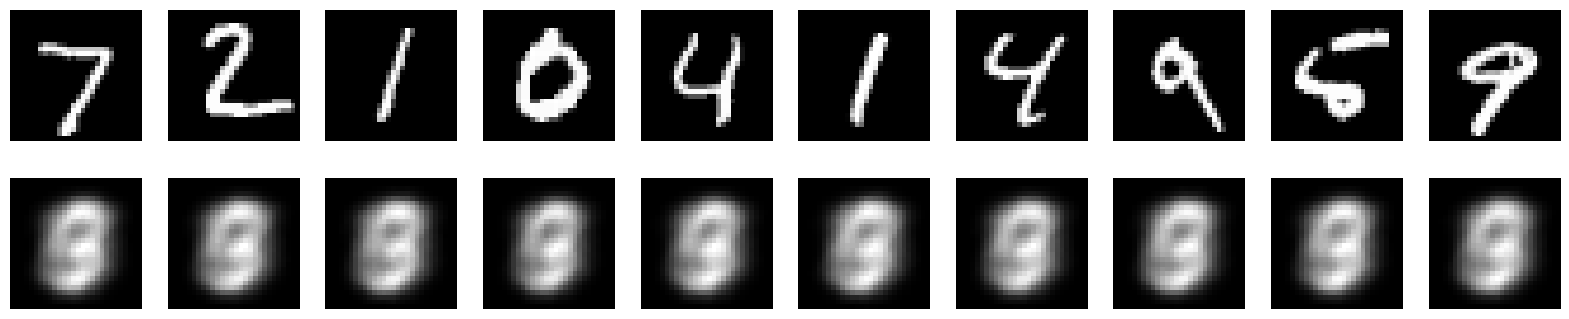

In [21]:
plt.figure(figsize=(20,4))

for i in range(10) :

  #original
  ax=plt.subplot(2,10,i+1)
  plt.imshow(
      x_test[i].reshape(28,28),
      cmap="gray"
  )
  plt.axis("off")

  #Reconstructed
  ax=plt.subplot(2,10,i+11)
  plt.imshow(
      reconstructed[i].reshape(28,28),
      cmap="gray"
  )
  plt.axis("off")

plt.show()